I. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from category_encoders import LeaveOneOutEncoder

II. PREPARE DATA

In [2]:
df =pd.read_csv('data.csv')
print(df.shape)

(35788, 15)


In [3]:
print(df.dtypes)

Thương hiệu           object
Model                 object
Tình trạng            object
Số Km đã đi            int64
Xuất xứ               object
Kiểu dáng             object
Hộp số                object
Số chỗ ngồi            int64
Số cửa                 int64
Dẫn động              object
Giá thành              int64
Loại nhiên liệu       object
Dung tích động cơ    float64
Đơn vị động cơ        object
Tuổi                   int64
dtype: object


In [4]:
# df[['Loại nhiên liệu', 'Dung tích động cơ', 'Đơn vị động cơ']] = df['Động cơ'].str.extract(r'(\D+) (\d+\.\d+) (\w+)')
# df=df.drop(['Động cơ'],axis =1)

In [5]:

missing_values = df.isnull().sum()
print(missing_values)

Thương hiệu          0
Model                0
Tình trạng           0
Số Km đã đi          0
Xuất xứ              0
Kiểu dáng            0
Hộp số               0
Số chỗ ngồi          0
Số cửa               0
Dẫn động             0
Giá thành            0
Loại nhiên liệu      0
Dung tích động cơ    0
Đơn vị động cơ       0
Tuổi                 0
dtype: int64


In [6]:

# df = df.dropna(subset=['Loại nhiên liệu'])
# df['Tuổi'] = 2023 - df['Năm sản xuất']
# df = df.drop(['Năm sản xuất'], axis=1)


In [7]:
df['Brand_Model'] = df['Thương hiệu'] + '_' + df['Model']

df.drop(columns=['Thương hiệu', 'Model'], inplace=True)

In [8]:
categorical_cols = ['Brand_Model', 'Tình trạng', 'Xuất xứ', 'Kiểu dáng', 'Hộp số', 'Dẫn động', 'Loại nhiên liệu']

for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"--- {col}: {len(unique_vals)} giá trị ---")
    print(unique_vals)
    print()

--- Brand_Model: 381 giá trị ---
['VinFast_Fadil' 'VinFast_Lux SA 2.0' 'Mazda_3' 'Kia_Cerato'
 'Ford_EcoSport' 'Ford_Ranger' 'Lexus_GX' 'Mercedes Benz_G class'
 'Mercedes Benz_S class' 'Ford_Territory' 'Chevrolet_Captiva'
 'Hyundai_i10' 'Mitsubishi_Triton' 'Ford_Fiesta' 'Mazda_2'
 'LandRover_Range Rover' 'Porsche_Macan' 'Ford_Everest' 'Hyundai_SantaFe'
 'Kia_Morning' 'Chevrolet_Aveo' 'Ford_Focus' 'VinFast_Lux A 2.0'
 'Hyundai_Veloster' 'Kia_Forte' 'Chevrolet_Cruze' 'Toyota_Camry'
 'Ford_Explorer' 'Mercedes Benz_C class' 'Mitsubishi_Outlander'
 'Peugeot_508' 'Mercedes Benz_GLC' 'Lexus_ES' 'Mitsubishi_Attrage'
 'Toyota_Vios' 'Mercedes Benz_GLE Class' 'Kia_Sonet' 'Mitsubishi_Grunder'
 'Mitsubishi_Xpander' 'Kia_K3' 'Kia_Carnival' 'Mitsubishi_Mirage'
 'Hyundai_Accent' 'Mercedes Benz_E class' 'Honda_CRV' 'Mercedes Benz_GLS'
 'Honda_City' 'Toyota_Prado' 'Lexus_RX' 'Subaru_Forester' 'Kia_Seltos'
 'BMW_5 Series' 'Mercedes Benz_GLB' 'Toyota_Highlander' 'Toyota_Fortuner'
 'Toyota_Innova' 'Nissan_

In [9]:
low_cardinality_cols = ['Xuất xứ', 'Kiểu dáng', 'Hộp số', 'Dẫn động', 'Loại nhiên liệu']
high_cardinality_cols = ['Brand_Model']

preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_cardinality_cols),
        ('target', LeaveOneOutEncoder(), high_cardinality_cols)
    ],
    remainder='passthrough'
)

# X_encoded = preprocessor.fit_transform(X, y)

In [10]:
df.drop(columns=["Đơn vị động cơ", "Số chỗ ngồi", "Số cửa", "Tình trạng"], inplace = True)

In [11]:
print(df.dtypes)

Số Km đã đi            int64
Xuất xứ               object
Kiểu dáng             object
Hộp số                object
Dẫn động              object
Giá thành              int64
Loại nhiên liệu       object
Dung tích động cơ    float64
Tuổi                   int64
Brand_Model           object
dtype: object


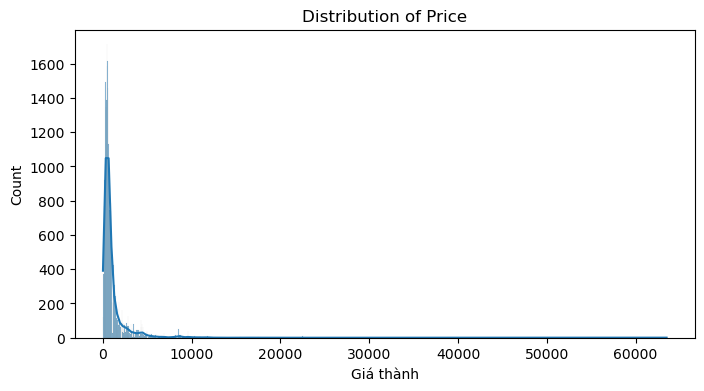

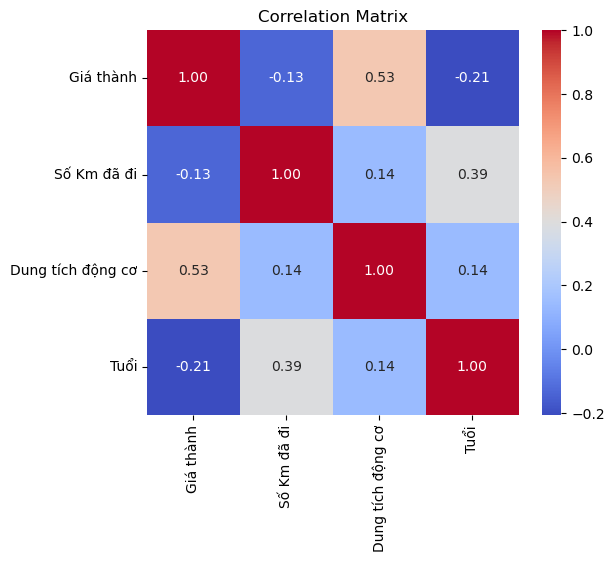

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Giá thành'], kde=True)
plt.title('Distribution of Price')
plt.show()

plt.figure(figsize=(6, 5))
num_cols = ['Giá thành', 'Số Km đã đi', 'Dung tích động cơ', 'Tuổi']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [13]:
df = df[df['Giá thành'] >= 30]

def filter_grouped_outliers(data, group_col, target_col):
    Q1 = data.groupby(group_col)[target_col].transform(lambda x: x.quantile(0.25))
    Q3 = data.groupby(group_col)[target_col].transform(lambda x: x.quantile(0.75))
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    counts = data.groupby(group_col)[target_col].transform('count')
    mask = ((data[target_col] >= lower) & (data[target_col] <= upper)) | (counts < 5)
    return data[mask]

df = filter_grouped_outliers(df, 'Brand_Model', 'Giá thành')

In [14]:
X = df.drop(columns=['Giá thành'])
y = np.log1p(df['Giá thành']) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

X_train_encoded = preprocessor.fit_transform(X_train, y_train)
X_test_encoded = preprocessor.transform(X_test)

onehot_cols = preprocessor.named_transformers_['onehot'].get_feature_names_out(low_cardinality_cols)
all_cols = list(onehot_cols) + high_cardinality_cols + ['Số Km đã đi', 'Dung tích động cơ', 'Tuổi']

X_train_df = pd.DataFrame(X_train_encoded, columns=all_cols, index=X_train.index)
X_test_df = pd.DataFrame(X_test_encoded, columns=all_cols, index=X_test.index)

pd.set_option('display.max_columns', None)

print("--- 5 Mẫu Dữ Liệu Train (Features đã mã hóa) ---")
display(X_train_df.head())

print("\n--- 5 Giá trị Target tương ứng (Đã biến đổi Logarit) ---")
print(y_train.head())

pd.reset_option('display.max_columns')

--- 5 Mẫu Dữ Liệu Train (Features đã mã hóa) ---


,Xuất xứ_Domestic,Xuất xứ_Imported,Kiểu dáng_Bán tải / Pickup,Kiểu dáng_Convertible/Cabriolet,Kiểu dáng_Coupe,Kiểu dáng_Crossover,Kiểu dáng_Hatchback,Kiểu dáng_SUV,Kiểu dáng_Sedan,Kiểu dáng_Truck,Kiểu dáng_Van/Minivan,Kiểu dáng_Wagon,Hộp số_Automatic,Hộp số_Manual,Dẫn động_4WD - 4 Wheel Drive,Dẫn động_FWD - Front Wheel Drive,Dẫn động_Full Time 4 Wheel Drive,Dẫn động_RFD - Rear Wheel Drive,Loại nhiên liệu_Diesel,Loại nhiên liệu_Electric,Loại nhiên liệu_Gas,Loại nhiên liệu_Hybrid,Brand_Model,Số Km đã đi,Dung tích động cơ,Tuổi
12019,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,7.011544,90000.0,1.8,13.0
4385,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,6.475029,0.0,1.5,0.0
6890,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,6.380498,0.0,2.2,6.0
4430,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,6.455828,50000.0,2.0,2.0
22015,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,6.629230,75000.0,2.5,8.0



--- 5 Giá trị Target tương ứng (Đã biến đổi Logarit) ---
12019    5.913503
4385     6.566672
6890     6.396930
4430     6.593045
22015    6.152733
Name: Giá thành, dtype: float64


III.    MODEL

In [15]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error 
import numpy as np

def calculate_mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

models_and_grids = {
    "Ridge Regression": {"model": Ridge(random_state=42), "params": {"alpha": [0.1, 1.0, 10.0]}},
    "Random Forest": {"model": RandomForestRegressor(random_state=42), "params": {"n_estimators": [100, 200], "max_depth": [10, 20, None]}},
    "Gradient Boosting": {"model": GradientBoostingRegressor(random_state=42), "params": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5, 7]}},
    "XGBoost": {"model": XGBRegressor(random_state=42, objective='reg:squarederror'), "params": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5, 7]}},
    "LightGBM": {"model": LGBMRegressor(random_state=42, verbose=-1), "params": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "num_leaves": [31, 63]}}
}

results = {}
print("Đang huấn luyện và tối ưu mô hình...\n")

for name, config in models_and_grids.items():
    search = RandomizedSearchCV(
        estimator=config["model"], param_distributions=config["params"],
        n_iter=10, cv=3, scoring='neg_mean_squared_error',
        random_state=42, n_jobs=-1
    )
    
    search.fit(X_train_df, y_train)
    best_model = search.best_estimator_
    
    log_predictions = best_model.predict(X_test_df)
    real_predictions = np.expm1(log_predictions)
    real_y_test = np.expm1(y_test)
    
    mae = mean_absolute_error(real_y_test, real_predictions)
    rmse = root_mean_squared_error(real_y_test, real_predictions) 
    mdape = calculate_mdape(real_y_test, real_predictions)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "MdAPE (%)": mdape, "Best Params": search.best_params_}
    print(f"Xong {name} | MdAPE: {mdape:.2f}% | MAE: {mae:,.0f}")

print("\n" + "="*40 + "\nKẾT QUẢ CHUNG CUỘC\n" + "="*40)
for name, metrics in results.items():
    print(f"{name}:\n  MdAPE: {metrics['MdAPE (%)']:.2f}%\n  MAE: {metrics['MAE']:,.0f}\n  RMSE: {metrics['RMSE']:,.0f}\n")

Đang huấn luyện và tối ưu mô hình...



d:\Applications\anaconda3\envs\my_conda_environment\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Xong Ridge Regression | MdAPE: 15.14% | MAE: 302


d:\Applications\anaconda3\envs\my_conda_environment\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Xong Random Forest | MdAPE: 10.94% | MAE: 253
Xong Gradient Boosting | MdAPE: 7.64% | MAE: 216
Xong XGBoost | MdAPE: 7.06% | MAE: 215


d:\Applications\anaconda3\envs\my_conda_environment\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Xong LightGBM | MdAPE: 7.37% | MAE: 216

KẾT QUẢ CHUNG CUỘC
Ridge Regression:
  MdAPE: 15.14%
  MAE: 302
  RMSE: 1,387

Random Forest:
  MdAPE: 10.94%
  MAE: 253
  RMSE: 1,329

Gradient Boosting:
  MdAPE: 7.64%
  MAE: 216
  RMSE: 1,378

XGBoost:
  MdAPE: 7.06%
  MAE: 215
  RMSE: 1,366

LightGBM:
  MdAPE: 7.37%
  MAE: 216
  RMSE: 1,087



In [16]:
import joblib
from xgboost import XGBRegressor

best_xgb_params = results['XGBoost']['Best Params']
final_model = XGBRegressor(random_state=42, objective='reg:squarederror', **best_xgb_params)
final_model.fit(X_train_df, y_train)

export_data = {
    'preprocessor': preprocessor,
    'model': final_model,
    'features': all_cols
}

joblib.dump(export_data, 'best_car_price_model.pkl')
print("Đã xuất thành công: 'best_car_price_model.pkl'")

Đã xuất thành công: 'best_car_price_model.pkl'
